<a href="https://colab.research.google.com/github/Abhishek3102/ML/blob/main/Dogs_vs_Cats_Classification_using_Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
!pip install kaggle

In [8]:
# Configuring the path of kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [9]:
!kaggle competitions download -c dogs-vs-cats

100% 811M/812M [00:07<00:00, 113MB/s]
100% 812M/812M [00:07<00:00, 111MB/s]


In [10]:
!ls

dogs-vs-cats.zip  kaggle.json  sample_data


In [11]:
from zipfile import ZipFile
dataset = '/content/dogs-vs-cats.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print("Done extracting the files")

Done extracting the files


In [12]:
from zipfile import ZipFile
dataset = '/content/train.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print("Done extracting the files")

Done extracting the files


In [13]:
import os
# Counting the number of files in train folder
path, dirs, files = next(os.walk("/content/train"))
file_count = len(files)
print("The number of images in the train folder is :", file_count)

The number of images in the train folder is : 25000


**Printing the names of images**

In [14]:
file_names = os.listdir("/content/train")
print(file_names)

['cat.7033.jpg', 'dog.7542.jpg', 'dog.5331.jpg', 'cat.9750.jpg', 'cat.2347.jpg', 'cat.5780.jpg', 'dog.5267.jpg', 'cat.10778.jpg', 'cat.2250.jpg', 'dog.10545.jpg', 'dog.4604.jpg', 'dog.3227.jpg', 'cat.4981.jpg', 'cat.10564.jpg', 'cat.7236.jpg', 'cat.5088.jpg', 'dog.11506.jpg', 'cat.1629.jpg', 'cat.12382.jpg', 'cat.8020.jpg', 'dog.3271.jpg', 'cat.8836.jpg', 'cat.11375.jpg', 'dog.7822.jpg', 'cat.6450.jpg', 'cat.1266.jpg', 'dog.3046.jpg', 'cat.11515.jpg', 'cat.6983.jpg', 'cat.1878.jpg', 'dog.5839.jpg', 'cat.1468.jpg', 'dog.10198.jpg', 'dog.2339.jpg', 'dog.12287.jpg', 'cat.4357.jpg', 'cat.1039.jpg', 'dog.9742.jpg', 'cat.2840.jpg', 'cat.10152.jpg', 'cat.10391.jpg', 'dog.9326.jpg', 'cat.2890.jpg', 'dog.5120.jpg', 'dog.12306.jpg', 'cat.618.jpg', 'dog.6592.jpg', 'cat.354.jpg', 'dog.4667.jpg', 'cat.8652.jpg', 'dog.10265.jpg', 'dog.2964.jpg', 'cat.4807.jpg', 'cat.1293.jpg', 'cat.4390.jpg', 'cat.1979.jpg', 'cat.2767.jpg', 'cat.10815.jpg', 'cat.11999.jpg', 'dog.185.jpg', 'dog.8197.jpg', 'cat.5812.j

In [15]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
import cv2
from google.colab.patches import cv2_imshow

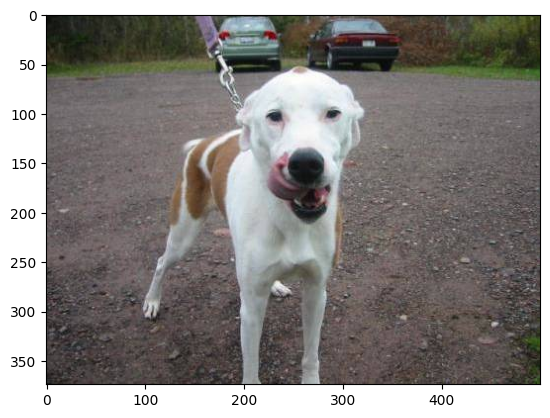

In [16]:
# Displaying a dog image
dog_image = mpimg.imread("/content/train/dog.8965.jpg")
plt.imshow(dog_image)

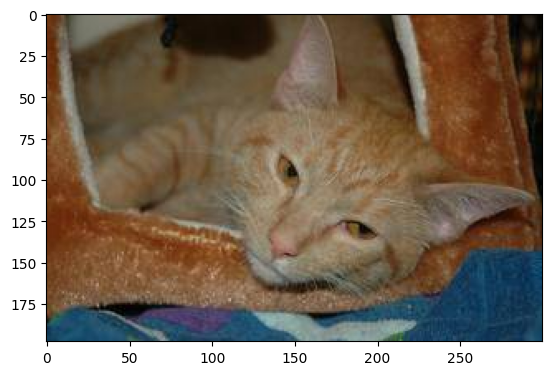

In [17]:
# Displaying an image of a cat
cat_image = mpimg.imread("/content/train/cat.6435.jpg")
plt.imshow(cat_image)

Finding the number of dogs and cats images

In [18]:
file_names = os.listdir("/content/train")
dog_count = 0
cat_count = 0

for file in file_names:
  if file.startswith("dog"):
    dog_count += 1
  elif file.startswith("cat"):
    cat_count += 1

print("The number of images of dogs in the train folder is: ", dog_count)
print("The number of images of cats in the train folder is: ", cat_count)

The number of images of dogs in the train folder is:  12500
The number of images of cats in the train folder is:  12500


Another way of finding the number of images of dogs and cats

In [19]:
file_names = os.listdir("/content/train")
dog_count = 0
cat_count = 0

for image_file in file_names:
  name = image_file[0:3]
  if name == 'dog':
    dog_count += 1
  elif name =='cat':
    cat_count += 1

print("The number of images of dogs in the train folder is: ", dog_count)
print("The number of images of cats in the train folder is: ", cat_count)

The number of images of dogs in the train folder is:  12500
The number of images of cats in the train folder is:  12500


Resizing all the images

In [20]:
os.mkdir("/content/resized images")

In [21]:
original_folder = "/content/train"
resized_folder = "/content/resized images"

for i in range(2000):
  filename = os.listdir(original_folder)[i]
  image_path = original_folder + "/" + filename
  image = Image.open(image_path)
  image = image.resize((224, 224))
  image = image.convert("RGB")

  new_image_path = resized_folder + "/" + filename
  image.save(new_image_path)

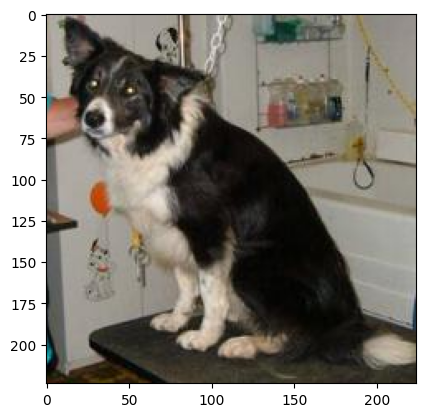

In [25]:
# Displaying the resized dog image
resized_dog_image = mpimg.imread("/content/resized images/dog.10050.jpg")
plt.imshow(resized_dog_image)

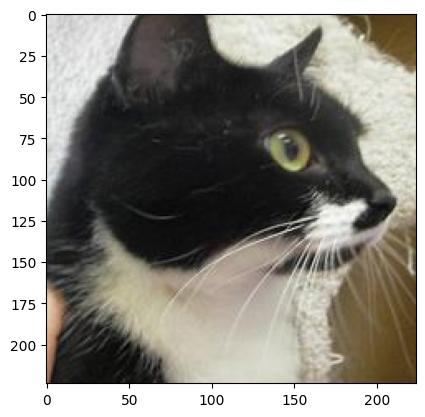

In [27]:
# Displaying the resized image of cat
resized_cat_image = mpimg.imread("/content/resized images/cat.6434.jpg")
plt.imshow(resized_cat_image)

Creating labels for resized Images of dogs and cats

Cat --> 0

Dog --> 1

In [28]:
filenames = os.listdir("/content/resized images")
labels = []
for i in range(2000):
  file_name = filenames[i]
  label = file_name[0:3]

  if label == "dog":
    labels.append(1)
  else:
    labels.append(0)

In [29]:
print(filenames[0:5])

['cat.7033.jpg', 'dog.7542.jpg', 'dog.5331.jpg', 'cat.9750.jpg', 'cat.2347.jpg']


In [30]:
print(labels[0:5])

[0, 1, 1, 0, 0]


In [33]:
# Counting the number of images of dogs and cats in 2000 images
values, counts = np.unique(labels, return_counts=True)
print(values)
print(counts)

[0 1]
[ 989 1011]


Converting all resized images to numpy arrays

In [34]:
import cv2
import glob

In [37]:
image_directory = "/content/resized images/"
image_extension = ['png','jpg']

files =[]

[files.extend(glob.glob(image_directory + '*.' + e)) for e in image_extension]

dog_cat_images = np.asarray([cv2.imread(file) for file in files])

In [38]:
print(dog_cat_images)

[[[[168 154 132]
   [164 150 128]
   [165 151 129]
   ...
   [114 105 138]
   [103  93 129]
   [ 96  85 123]]

  [[170 156 134]
   [170 156 134]
   [170 156 134]
   ...
   [116 108 139]
   [113 104 137]
   [110 100 136]]

  [[169 155 133]
   [175 161 139]
   [178 164 142]
   ...
   [120 112 142]
   [118 110 141]
   [117 109 140]]

  ...

  [[ 87  84  79]
   [ 88  85  80]
   [ 89  86  81]
   ...
   [220 212 243]
   [222 214 245]
   [224 216 247]]

  [[ 86  82  77]
   [ 87  83  78]
   [ 88  85  77]
   ...
   [223 215 245]
   [221 213 243]
   [219 211 241]]

  [[ 83  79  74]
   [ 84  80  75]
   [ 86  83  75]
   ...
   [226 218 248]
   [221 213 243]
   [215 207 237]]]


 [[[ 42  68  85]
   [ 42  68  85]
   [ 40  66  83]
   ...
   [ 18  16  16]
   [ 24  22  12]
   [ 17  14   0]]

  [[ 43  69  85]
   [ 39  65  81]
   [ 34  60  76]
   ...
   [ 14  11  13]
   [ 21  18  10]
   [ 22  18   7]]

  [[ 40  68  79]
   [ 43  71  82]
   [ 43  71  82]
   ...
   [ 12   8  14]
   [ 14  10   9]
   [ 22  18

In [39]:
type(dog_cat_images)

numpy.ndarray

In [41]:
print(dog_cat_images.shape)
# Here 2000 is the number of images of dogs and cats, 224 x 224 is the dimension and 3 is for showing that these are rgb images

(2000, 224, 224, 3)


In [42]:
X = dog_cat_images
Y = np.asarray(labels)

**Train Test Split**

In [43]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [44]:
print(X.shape, X_train.shape, X_test.shape)

(2000, 224, 224, 3) (1600, 224, 224, 3) (400, 224, 224, 3)


**1600 --> Training Images**

**400 --> Test Images**

In [45]:
# Scaling the data
X_train_scaled = X_train/255
X_test_scaled = X_test/255

In [46]:
print(X_train_scaled)

[[[[0.32156863 0.35686275 0.39607843]
   [0.2627451  0.29803922 0.3372549 ]
   [0.2745098  0.30980392 0.34901961]
   ...
   [0.48627451 0.34117647 0.2627451 ]
   [0.50196078 0.36078431 0.29803922]
   [0.51764706 0.38431373 0.32156863]]

  [[0.37647059 0.4        0.44313725]
   [0.31764706 0.35294118 0.39215686]
   [0.3254902  0.34901961 0.39215686]
   ...
   [0.46666667 0.30980392 0.23921569]
   [0.48235294 0.32941176 0.27058824]
   [0.49803922 0.35686275 0.29411765]]

  [[0.34901961 0.36862745 0.40392157]
   [0.31764706 0.34509804 0.38039216]
   [0.34117647 0.36078431 0.39607843]
   ...
   [0.47058824 0.29411765 0.23921569]
   [0.48627451 0.31372549 0.2627451 ]
   [0.49803922 0.33333333 0.28235294]]

  ...

  [[0.74117647 0.69411765 0.68627451]
   [0.74117647 0.69411765 0.68627451]
   [0.7372549  0.69019608 0.68235294]
   ...
   [0.68235294 0.63921569 0.62352941]
   [0.69411765 0.65098039 0.63529412]
   [0.69803922 0.65490196 0.63921569]]

  [[0.73333333 0.68627451 0.67843137]
   [0.7

**Building the Neural Network**

In [49]:
import tensorflow as tf
from tensorflow import keras
import tensorflow_hub as hub

In [52]:
import tensorflow_hub as hub
m = tf.keras.Sequential(
    hub.KerasLayer("https://www.kaggle.com/models/google/mobilenet-v2/TensorFlow2/tf2-preview-feature-vector/4",
                   trainable=False))  # Can be True, see below.

# m.build([224, 224, 3])  # Batch input shape.


In [54]:
mobilenet_model = "https://www.kaggle.com/models/google/mobilenet-v2/TensorFlow2/tf2-preview-feature-vector/4"
pretrained_model = hub.KerasLayer(mobilenet_model, input_shape=(224,224,3), trainable=False)

In [55]:
num_of_classes = 2

model = tf.keras.Sequential([
    pretrained_model,
    tf.keras.layers.Dense(num_of_classes)
])

model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 keras_layer_3 (KerasLayer)  (None, 1280)              2257984   
                                                                 
 dense (Dense)               (None, 2)                 2562      
                                                                 
Total params: 2260546 (8.62 MB)
Trainable params: 2562 (10.01 KB)
Non-trainable params: 2257984 (8.61 MB)
_________________________________________________________________


In [56]:
model.compile(optimizer='adam',
              loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [57]:
model.fit(X_train_scaled, Y_train, epochs=5)

Epoch 1/5
50/50 [==============================] - 73s 1s/step - loss: 0.2181 - accuracy: 0.9069
Epoch 2/5
50/50 [==============================] - 63s 1s/step - loss: 0.0681 - accuracy: 0.9775
Epoch 3/5
50/50 [==============================] - 60s 1s/step - loss: 0.0523 - accuracy: 0.9831
Epoch 4/5
50/50 [==============================] - 60s 1s/step - loss: 0.0429 - accuracy: 0.9856
Epoch 5/5
50/50 [==============================] - 61s 1s/step - loss: 0.0340 - accuracy: 0.9900


In [58]:
score, acc = model.evaluate(X_test_scaled, Y_test)
print("Test loss", score)
print("Test Accuracy", acc)

13/13 [==============================] - 17s 1s/step - loss: 0.0704 - accuracy: 0.9700
Test loss 0.07041138410568237
Test Accuracy 0.9700000286102295


**Predictive System**

Path of image to be predicted: /content/1.jpg


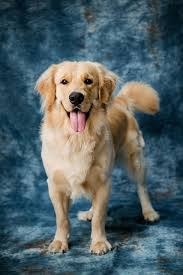

1/1 [==============================] - 0s 52ms/step
[[-4.2689276  3.2515137]]
1
The image is of a dog


In [60]:
input_image_path = input('Path of image to be predicted: ')
input_image = cv2.imread(input_image_path)
cv2_imshow(input_image)

input_image_resize = cv2.resize(input_image, (224,224))

input_image_rescaled = input_image_resize/255

image_reshaped = np.reshape(input_image_rescaled, [1,224,224,3])

input_prediction = model.predict(image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label == 0:
  print("The image is of a cat")
else:
  print("The image is of a dog")

Path of image to be predicted: /content/0.jpg


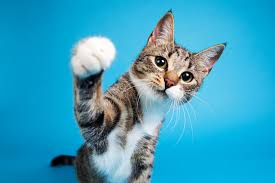

1/1 [==============================] - 0s 50ms/step
[[ 3.9550679 -4.3475704]]
0
The image is of a cat


In [61]:
input_image_path = input('Path of image to be predicted: ')
input_image = cv2.imread(input_image_path)
cv2_imshow(input_image)

input_image_resize = cv2.resize(input_image, (224,224))

input_image_rescaled = input_image_resize/255

image_reshaped = np.reshape(input_image_rescaled, [1,224,224,3])

input_prediction = model.predict(image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label == 0:
  print("The image is of a cat")
else:
  print("The image is of a dog")